# Task 3: Evaluate Deforestation through Bitemporal Change Detection

In this final task we quantify deforestation in São Félix do Xingu based on bitemporal satellite observations. We rely on the Sentinel-2 tile **T22MCU** previously downloaded and visualized in Task 1, and use the CNN-based segmentation model from Task 2 for comparison. Our objective is to measure both absolute and relative forest loss between 2018 and 2024.

In this task we perform quantitative change detection at the patch level using two complementary approaches:

- **NDVI differencing**: exploiting spectral vegetation indices sensitive to chlorophyll absorption.
- **CNN segmentation differencing**: based on pixelwise classification models trained for forest cover detection.

The combined evaluation enables us to assess the agreement between physical indices and data-driven model outputs while identifying specific strengths and limitations of both approaches. 

We focus on tile **T22MCU** which covers one of the most deforested sectors in the municipality and shows strong spatial variability in canopy loss. 

**Important Note**

If you were not able to complete Task 1 or Task 2, we provide a preprocessed version of the tile and a pretrained CNN model for this task. Please use these resources if necessary.
The model can be loaded with `model = torch.jit.load("backup_model.pt")`




## Imports

In [1]:
import os
import rootutils
root = rootutils.setup_root(os.path.abspath(''), dotenv=True, pythonpath=True, cwd=False)

data_path = root / "data"
data_path.mkdir(exist_ok=True)
output_dir = root / "output"
output_dir.mkdir(exist_ok=True)

tile_dir = data_path / "T22MCU"
tile_dir.mkdir(exist_ok=True)
save_dir = output_dir / "task3_patches"
save_dir.mkdir(exist_ok=True)
models_dir = root / "models"
root

PosixPath('/Users/yuntingchiu/Development/ipl4eo-2026-project-public')

In [2]:
from abc import ABC, abstractmethod
from pathlib import Path
from typing import Dict, Tuple, Optional
from dataclasses import dataclass, field
import numpy as np
import torchvision.transforms as transforms
from matplotlib import pyplot as plt
from tqdm import tqdm
import torch
import sys
from PIL import Image
from torch.utils.data import Dataset, DataLoader

import lightning as L
import torch.nn.functional as F
from huggingface_hub import PyTorchModelHubMixin
from types import SimpleNamespace
from configilm import ConfigILM
import torch.nn as nn
from torchmetrics.classification import MulticlassJaccardIndex

import rasterio
from rasterio.enums import Resampling
from rasterio.windows import Window

PATCH_SIZE = 120
YEARS = [2018, 2024]

CORRECT_BANDORDER = ['B02_10m', 'B03_10m', 'B04_10m', 'B05_20m', 'B06_20m', 'B07_20m', 'B08_10m', 'B8A_20m', 'B11_20m', 'B12_20m']

## 3.1 Patch Extraction and Preprocessing

- Load the tile

- Perform bilinear interpolation of 20m bands to 10m spatial resolution (e.g. with [Rasterio](https://rasterio.readthedocs.io/en/stable/topics/resampling.html))

- Divide the tile into non-overlapping patches of size **120 x 120 pixels** for the model. Be sure to deal with borders correctly. If the tile is not slizable in 120x120 non-overlapping patches starting from top left drop the edges. Save these patches somewhere as they will be used for subsequent analysis.


##### `get_band_paths(year)`

Return

```python
{
    "BO2_10m": Path(...),
    "B03_10m": Path(...),
}
```

In [3]:
def get_band_paths(year):
    year_dir = tile_dir / str(year)

    band_paths = {
        band_name: year_dir / f"{band_name}.jp2"
        for band_name in CORRECT_BANDORDER
    }

    for band_name, path in band_paths.items():
        if not path.exists():
            raise FileNotFoundError(f"Missing {band_name}: {path}")

    return band_paths

##### `get_image_shape(image_path)`

Return
```python
(height, width)
```

In [4]:
def get_image_shape(image_path):
    with rasterio.open(image_path) as band_img_src:
        return band_img_src.height, band_img_src.width

##### `read_band_patch(band_img_src, band_name, top, left)`

Return
```python
patch # patch.shape: (120, 120)
```

In [5]:
def read_band_patch(band_img_src, band_name, top, left):
    if band_name.endswith("_10m"):
        window = Window(
            col_off=left,
            row_off=top,
            width=PATCH_SIZE,
            height=PATCH_SIZE,
        )
        patch = band_img_src.read(
            1,
            window=window,
        )

    elif band_name.endswith("_20m"):
        window = Window(
            col_off=left//2,
            row_off=top//2,
            width=PATCH_SIZE//2,
            height=PATCH_SIZE//2,
        )
        patch = band_img_src.read(
            1,
            window=window,
            out_shape=(PATCH_SIZE, PATCH_SIZE),
            resampling=Resampling.bilinear,
        )

    else:
        raise ValueError(f"Unknown resolution: {band_name}")

    if patch.shape != (PATCH_SIZE, PATCH_SIZE):
        raise ValueError(f"Unexpected patch shape for {band_name}: {patch.shape}")

    # patch.shape = (120, 120)
    return patch.astype(np.float32)

##### `extract_patches_for_year(year)`

In [6]:
def extract_patches_for_year(year):
    patches_path = save_dir / f"patches_{year}.npy"
    positions_path = save_dir / f"positions_{year}.npy"

    band_paths = get_band_paths(year)

    # reference
    height, width = get_image_shape(band_paths["B02_10m"])

    usable_height = (height // PATCH_SIZE) * PATCH_SIZE
    usable_width = (width // PATCH_SIZE) * PATCH_SIZE

    num_patch_rows = usable_height // PATCH_SIZE
    num_patch_cols = usable_width // PATCH_SIZE
    num_patches = num_patch_rows * num_patch_cols

    # initialization
    patches = np.lib.format.open_memmap(
        patches_path,
        mode="w+",
        dtype=np.float32,
        shape=(
            num_patches,
            len(CORRECT_BANDORDER),
            PATCH_SIZE,
            PATCH_SIZE,
        ),
    )
    positions = np.empty((num_patches, 2), dtype=np.int32)
    band_img_sources = {}

    try:
        band_img_sources = {
            band_name: rasterio.open(path)
            for band_name, path in band_paths.items()
        }

        patch_index = 0
        for top in tqdm(range(0, usable_height, PATCH_SIZE), desc=f"Extracting {year}"):
            for left in range(0, usable_width, PATCH_SIZE):
                positions[patch_index] = (top, left)

                for band_index, band_name in enumerate(CORRECT_BANDORDER):
                    patches[patch_index, band_index] = read_band_patch(
                        band_img_src=band_img_sources[band_name],
                        band_name=band_name,
                        top=top,
                        left=left,
                    )

                patch_index += 1

        np.save(positions_path, positions)

    finally:
        patches.flush()

        for band_img_src in band_img_sources.values():
            band_img_src.close()

    return {
        "patches_path": patches_path,
        "positions_path": positions_path,
        "shape": (
            num_patches,
            len(CORRECT_BANDORDER),
            PATCH_SIZE,
            PATCH_SIZE,
        ),
        "image_shape": (height, width),
        "usable_shape": (usable_height, usable_width),
        "patch_grid_shape": (num_patch_rows, num_patch_cols),
    }

In [7]:
band_paths_2018 = get_band_paths(2018)
band_paths_2024 = get_band_paths(2024)

shape_2018 = get_image_shape(band_paths_2018["B02_10m"])
shape_2024 = get_image_shape(band_paths_2024["B02_10m"])

if shape_2018 != shape_2024:
    raise ValueError("2018 and 2024 tiles have different shapes")

result_2018 = extract_patches_for_year(2018)
result_2024 = extract_patches_for_year(2024)

Extracting 2024: 100%|███████████████████████████████████████████████████████████████████████████████████████| 91/91 [00:20<00:00,  4.41it/s]


In [8]:
positions_2018 = np.load(result_2018["positions_path"])
positions_2024 = np.load(result_2024["positions_path"])

assert np.array_equal(
    positions_2018,
    positions_2024,
), "2018 and 2024 patch positions do not match"

In [12]:
band_paths_2018

{'B02_10m': PosixPath('/Users/yuntingchiu/Development/ipl4eo-2026-project-public/data/T22MCU/2018/B02_10m.jp2'),
 'B03_10m': PosixPath('/Users/yuntingchiu/Development/ipl4eo-2026-project-public/data/T22MCU/2018/B03_10m.jp2'),
 'B04_10m': PosixPath('/Users/yuntingchiu/Development/ipl4eo-2026-project-public/data/T22MCU/2018/B04_10m.jp2'),
 'B05_20m': PosixPath('/Users/yuntingchiu/Development/ipl4eo-2026-project-public/data/T22MCU/2018/B05_20m.jp2'),
 'B06_20m': PosixPath('/Users/yuntingchiu/Development/ipl4eo-2026-project-public/data/T22MCU/2018/B06_20m.jp2'),
 'B07_20m': PosixPath('/Users/yuntingchiu/Development/ipl4eo-2026-project-public/data/T22MCU/2018/B07_20m.jp2'),
 'B08_10m': PosixPath('/Users/yuntingchiu/Development/ipl4eo-2026-project-public/data/T22MCU/2018/B08_10m.jp2'),
 'B8A_20m': PosixPath('/Users/yuntingchiu/Development/ipl4eo-2026-project-public/data/T22MCU/2018/B8A_20m.jp2'),
 'B11_20m': PosixPath('/Users/yuntingchiu/Development/ipl4eo-2026-project-public/data/T22MCU/201

In [13]:
shape_2018

(10980, 10980)

In [14]:
result_2018

{'patches_path': PosixPath('/Users/yuntingchiu/Development/ipl4eo-2026-project-public/output/task3_patches/patches_2018.npy'),
 'positions_path': PosixPath('/Users/yuntingchiu/Development/ipl4eo-2026-project-public/output/task3_patches/positions_2018.npy'),
 'shape': (8281, 10, 120, 120),
 'image_shape': (10980, 10980),
 'usable_shape': (10920, 10920),
 'patch_grid_shape': (91, 91)}

## 3.2 Change detection

### 3.2.1 NDVI and CNN Mask Calculation

For each extracted patch compute (pixel-wise):

 a. NDVI
 
 b. CNN Mask
    - Apply the CNN segmentation model from Task 2 to each patch. (Note: don't forget to preprocess)
    
To convert it into a binary mask, find a good threshhold. Argue your choice for the NDVI and CNN.

In [15]:
patches_2018 = np.load(result_2018["patches_path"],mmap_mode="r")
patches_2024 = np.load(result_2024["patches_path"],mmap_mode="r")

print(patches_2018.shape)
print(patches_2024.shape)

(8281, 10, 120, 120)
(8281, 10, 120, 120)


#### 3.2.1.0 NDVI

##### Calculate NDVI

In [16]:
RED_INDEX = 2 # B04
NIR_INDEX = 6 # B08

def calculate_ndvi(patches):
    red = patches[:, RED_INDEX].astype(np.float32)
    nir = patches[:, NIR_INDEX].astype(np.float32)

    numerator = nir - red      # [num_patches, 120, 120]
    denominator = nir + red    # [num_patches, 120, 120]

    # [num_patches, 120, 120]
    return np.divide(
        numerator,
        denominator,
        out=np.zeros_like(denominator),
        where=denominator != 0,        
    )

In [17]:
ndvi_2018 = calculate_ndvi(patches_2018) # [num_patches, 120, 120]
ndvi_2024 = calculate_ndvi(patches_2024) # [num_patches, 120, 120]

print(ndvi_2018.shape)
print(ndvi_2018.min(), ndvi_2018.max())

print(ndvi_2024.shape)
print(ndvi_2024.min(), ndvi_2024.max())

(8281, 120, 120)
-0.38518956 1.0
(8281, 120, 120)
-0.37269372 0.76803964


##### Threshold selection

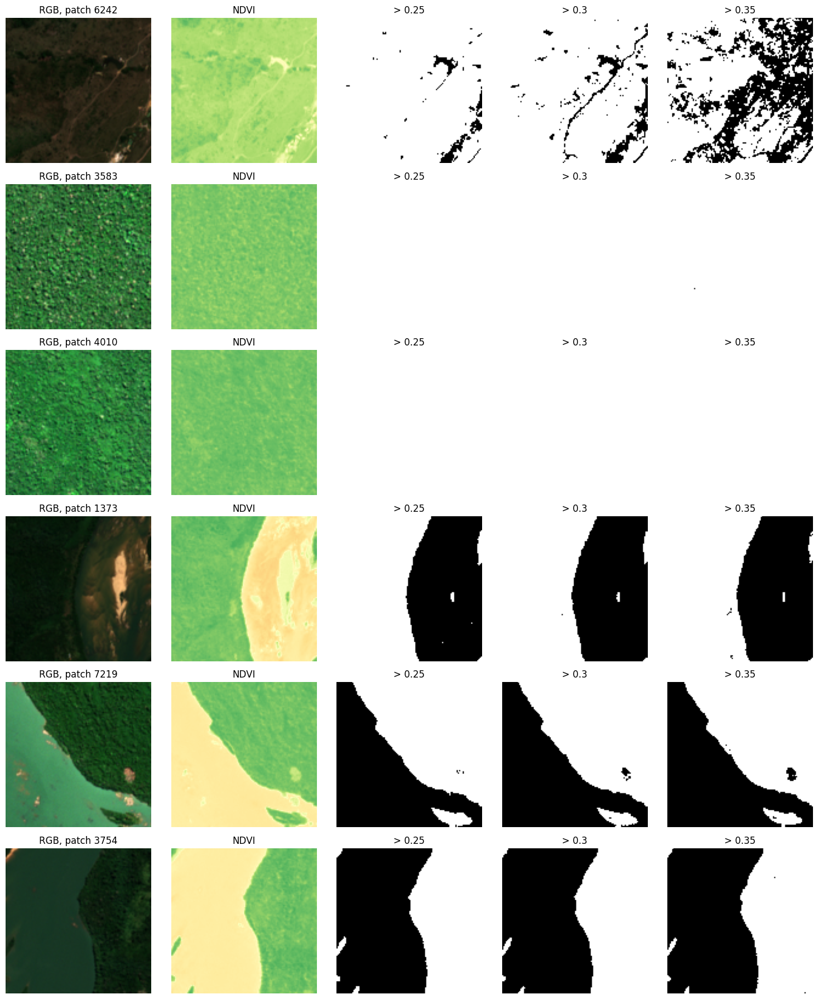

In [18]:
patch_means = ndvi_2018.mean(axis=(1, 2))  # (num_patches,)
patch_stds = ndvi_2018.std(axis=(1, 2))    # (num_patches,)
# patch_means[i]: NDVI mean of patch i
# patch_stds[i]: NDVI std of patch i

# select patches near different percentiles (10th, 50th, 90th) of mean NDVI
indices = [
    np.argmin(abs(patch_means - np.quantile(patch_means, q)))
    for q in [0.1, 0.5, 0.9]
]
# select the patch with top 3 highest NDVI variation
high_std_indices = np.argsort(patch_stds)[-3:][::-1]
indices = list(dict.fromkeys([*indices, *high_std_indices]))

def plot_threshold_examples(patches, scores, indices, thresholds):
    rows = len(indices)
    cols = 2 + len(thresholds)

    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))

    for row, index in enumerate(indices):
        patch = patches[index]
        score = scores[index]

        rgb = patch[[2, 1, 0]].transpose(1, 2, 0)
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

        axes[row, 0].imshow(rgb)
        axes[row, 0].set_title(f"RGB, patch {index}")

        axes[row, 1].imshow(score, vmin=-1, vmax=1, cmap="RdYlGn")
        axes[row, 1].set_title("NDVI")

        for col, threshold in enumerate(thresholds, start=2):
            axes[row, col].imshow(score > threshold, vmin=0, vmax=1, cmap="gray")
            # score > threshold: False / 0 -> non-forest, black
            # score !> threshold: True / 1 -> forest, white
            axes[row, col].set_title(f"> {threshold}")

        for ax in axes[row]:
            ax.axis("off")

    plt.tight_layout()

plot_threshold_examples(
    patches_2018,
    ndvi_2018,
    indices,
    thresholds=[0.25, 0.3, 0.35],
)

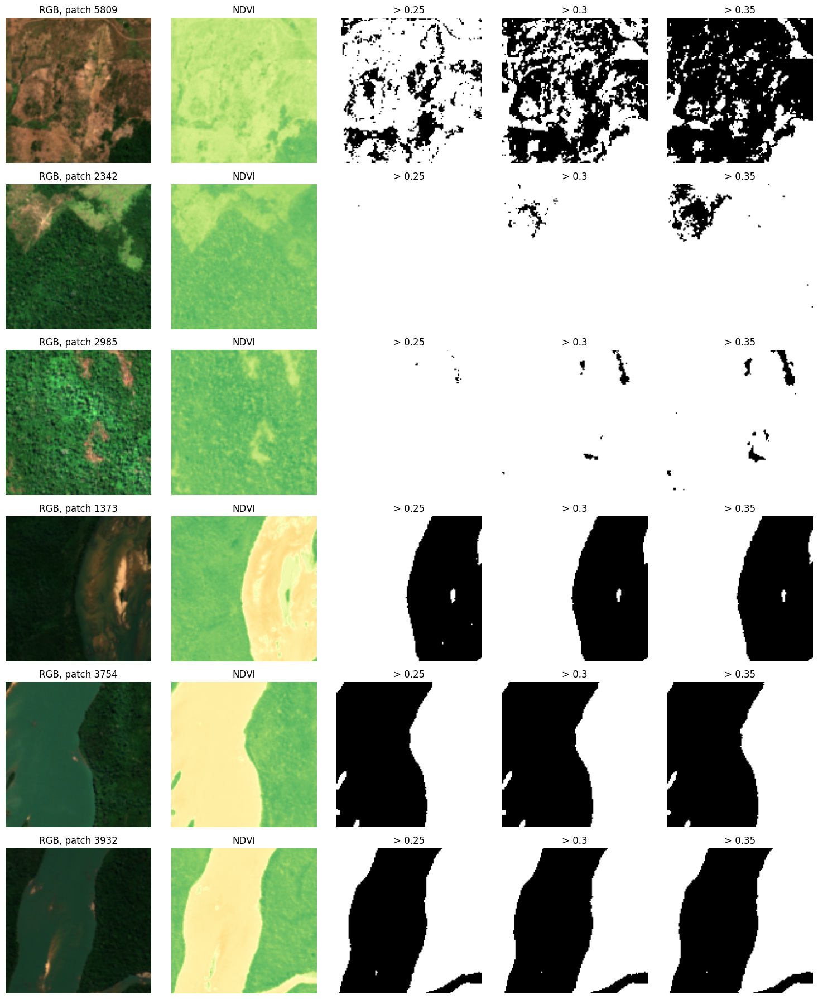

In [19]:
patch_means = ndvi_2024.mean(axis=(1, 2))  # (num_patches,)
patch_stds = ndvi_2024.std(axis=(1, 2))    # (num_patches,)
# patch_means[i]: NDVI mean of patch i
# patch_stds[i]: NDVI std of patch i

# select patches near different percentiles (10th, 50th, 90th) of mean NDVI
indices = [
    np.argmin(abs(patch_means - np.quantile(patch_means, q)))
    for q in [0.1, 0.5, 0.9]
]
# select the patch with top 3 highest NDVI variation
high_std_indices = np.argsort(patch_stds)[-3:][::-1]
indices = list(dict.fromkeys([*indices, *high_std_indices]))

def plot_threshold_examples(patches, scores, indices, thresholds):
    rows = len(indices)
    cols = 2 + len(thresholds)

    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))

    for row, index in enumerate(indices):
        patch = patches[index]
        score = scores[index]

        rgb = patch[[2, 1, 0]].transpose(1, 2, 0)
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

        axes[row, 0].imshow(rgb)
        axes[row, 0].set_title(f"RGB, patch {index}")

        axes[row, 1].imshow(score, vmin=-1, vmax=1, cmap="RdYlGn")
        axes[row, 1].set_title("NDVI")

        for col, threshold in enumerate(thresholds, start=2):
            axes[row, col].imshow(score > threshold, vmin=0, vmax=1, cmap="gray")
            # score > threshold: False / 0 -> non-forest, black
            # score !> threshold: True / 1 -> forest, white
            axes[row, col].set_title(f"> {threshold}")

        for ax in axes[row]:
            ax.axis("off")

    plt.tight_layout()

plot_threshold_examples(
    patches_2024,
    ndvi_2024,
    indices,
    thresholds=[0.25, 0.3, 0.35],
)

In [20]:
NDVI_THRESHOLD = 0.3

An NDVI threshold of 0.3 was chosen because it best preserved visible forest while excluding bare land. Lower values were too permissive, while 0.35 removed too much vegetation.

##### <mark>NVDI masks</mark>

In [21]:
ndvi_masks_2018 = ndvi_2018 > NDVI_THRESHOLD # [num_patches, 120, 120]
ndvi_masks_2024 = ndvi_2024 > NDVI_THRESHOLD # [num_patches, 120, 120]

if ndvi_masks_2018.shape != ndvi_masks_2024.shape:
    raise ValueError("2018 and 2024 NDVI masks must have the same shape")

In [22]:
np.save(save_dir / "ndvi_2018.npy", ndvi_2018)
np.save(save_dir / "ndvi_2024.npy", ndvi_2024)

np.save(save_dir / "ndvi_masks_2018.npy", ndvi_masks_2018)
np.save(save_dir / "ndvi_masks_2024.npy", ndvi_masks_2024)

#### 3.2.1.1 CNN

##### From Task 2

In [23]:
class Resnet(L.LightningModule, PyTorchModelHubMixin):
    def __init__(self, config):
        super().__init__()
        self.config = SimpleNamespace(**config)
        self.model = ConfigILM.ConfigILM(self.config)

    def forward(self, x):
        return self.model(x)

pretrained_model_skip = Resnet.from_pretrained("BIFOLD-BigEarthNetv2-0/resnet18-s2-v0.2.0").model.vision_encoder
children_skip = list(pretrained_model_skip.children())

class DecoderBlock(nn.Module):
    """Upsample to skip's spatial size, concatenate, then Conv+BN+ReLU."""

    def __init__(self, in_ch, skip_ch, out_ch):
        """
        in_ch: input channels of decoder
        skip_ch: output channels of encoder skip
        out_ch: output channels of decoder
        """
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch + skip_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x, skip):
        """
        x: input of the decoder
        skip: output of the skip encoder
        """
        # scale x to the [H, W] of skip
        x = F.interpolate(
            x,
            size=skip.shape[-2:],   # [H, W]
            mode='bilinear',
            align_corners=False
        )
        return self.conv(torch.cat([x, skip], dim=1))


class FCNResnetSkip(L.LightningModule):
    def __init__(self, num_classes=2, learning_rate=1e-4):
        super().__init__()
        self.learning_rate = learning_rate
        self.num_classes = num_classes
        # self.mIoU = MeanIoU(num_classes=num_classes)
        self.mIoU = MulticlassJaccardIndex(
            num_classes=num_classes,
            average="macro",
        )
        # self.val_outputs = []
        # self.test_outputs = []

        # Backbone split into named stages to expose intermediate feature maps
        self.stem   = nn.Sequential(*children_skip[:4])   # -> 30x30, 64ch
        self.layer1 = children_skip[4]                    # -> 30x30, 64ch
        self.layer2 = children_skip[5]                    # -> 15x15, 128ch
        self.layer3 = children_skip[6]                    # ->  8x8,  256ch
        self.layer4 = children_skip[7]                    # ->  4x4,  512ch

        for module in [self.stem, self.layer1, self.layer2, self.layer3, self.layer4]:
            for p in module.parameters():
                p.requires_grad = False

        # TODO: Replace None with DecoderBlock(in_ch, skip_ch, out_ch).
        # Use the table in the description to find the correct channel numbers.
        self.dec3 = DecoderBlock(512, 256, 128)  
        self.dec2 = DecoderBlock(128, 128, 64)
        self.dec1 = DecoderBlock(64, 64, 32)

        # [B, 32, 120, 120] -> [B, num_classes, 120, 120]
        self.head = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        # TODO: Run x through each backbone stage and save intermediate feature maps.
        # Then call dec3, dec2, dec1 with the correct skip connections.
        # Upsample the final output to (120, 120) and apply self.head.
        
        final_output_size = x.shape[-2:]     # [120, 120]
        
        output_stem = self.stem(x)           # [B, 64, 30, 30]
        skip1 = self.layer1(output_stem)     # [B, 64, 30, 30]
        skip2 = self.layer2(skip1)           # [B, 128, 15, 15]
        skip3 = self.layer3(skip2)           # [B, 256, 8, 8]
        skip4 = self.layer4(skip3)           # [B, 512, 4, 4]

        dec3 = self.dec3(skip4, skip3)       # [B, 128, 8, 8]
        dec2 = self.dec2(dec3, skip2)        # [B, 64, 15, 15]
        dec1 = self.dec1(dec2, skip1)        # [B, 32, 30, 30]

        scale_dec1 = F.interpolate(
            dec1,
            size=final_output_size,
            mode="bilinear",
            align_corners=False,
        )                                    # [B, 32, 120, 120]

        output = self.head(scale_dec1)       # [B, 2, 120, 120]
        return output

    def training_step(self, batch, batch_idx):
        images, masks = batch

        logits = self(images)
        loss = F.cross_entropy(logits, masks)

        self.log(
            "train_loss",
            loss,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            batch_size=images.size(0),
        )

        return loss

    def validation_step(self, batch, batch_idx):
        images, masks = batch
    
        logits = self(images)
        loss = F.cross_entropy(logits, masks)
        preds = logits.argmax(dim=1)
    
        self.mIoU.update(preds, masks)
    
        self.log(
            "val_loss",
            loss,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            batch_size=images.size(0),
        )

    def on_validation_epoch_end(self):
        miou = self.mIoU.compute()
        self.mIoU.reset()
    
        print("validation mIoU:", miou.item())
    
        self.log(
            "val_mIoU",
            miou,
            prog_bar=True,
            on_step=False,
            on_epoch=True,
        )

    def test_step(self, batch, batch_idx):
        images, masks = batch
    
        logits = self(images)
        loss = F.cross_entropy(logits, masks)
        preds = logits.argmax(dim=1)
    
        self.mIoU.update(preds, masks)
    
        self.log(
            "test_loss",
            loss,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            batch_size=images.size(0),
        )
    
    
    def on_test_epoch_end(self):
        miou = self.mIoU.compute()
        self.mIoU.reset()
    
        print("test mIoU:", miou.item())
        self.log("test_mIoU", miou, prog_bar=True)

    def configure_optimizers(self):
        trainable_parameters = filter(
            lambda parameter: parameter.requires_grad,
            self.parameters()
        )

        optimizer = torch.optim.Adam(
            trainable_parameters,
            lr=self.learning_rate,
        )

        return optimizer

/Users/yuntingchiu/Development/ipl4eo-2026-project-public/.venv/lib/python3.12/site-packages/configilm/ConfigILM.py:134: UserWarning: Keyword 'img_size' unknown. Trying to ignore and restart creation.
  warnings.warn(f"Keyword '{failed_kw}' unknown. Trying to ignore and restart creation.")


In [24]:
mean = [1278.22943098, 1525.50352811, 1472.70851943, 1980.25337636, 3299.47598865, 3810.3546167, 3966.00902336, 4159.42767302, 3138.13795129, 2108.08627312]
std  = [158.01445714, 217.62486718, 379.96948042, 390.48622488, 325.42077925, 452.74948481, 535.93502982, 445.17587779, 773.81740343, 600.97175751]

mean_tensor = torch.tensor(mean, dtype=torch.float32)[:, None, None]
std_tensor = torch.tensor(std, dtype=torch.float32)[:, None, None]

##### Load best checkpoint

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FCNResnetSkip.load_from_checkpoint(models_dir/"best_skip.ckpt")

model.to(device)
model.eval()

FCNResnetSkip(
  (mIoU): MulticlassJaccardIndex()
  (stem): Sequential(
    (0): Conv2d(10, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act1): ReLU(inplace=True)
      (aa): Identity()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act2): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding

##### Patch dataset

In [26]:
class PatchDataset(Dataset):
    def __init__(self, patches):
        self.patches = patches     # [num_patches, 10, 120, 120]

    def __len__(self):
        return len(self.patches)   # num_patches

    def __getitem__(self, index):
        patch = torch.tensor(
            self.patches[index],   # [10, 120, 120]
            dtype=torch.float32,
        )
        return (patch-mean_tensor) / std_tensor   # normalization, [10, 120, 120]

In [27]:
loader_2018 = DataLoader(PatchDataset(patches_2018), batch_size=32, shuffle=False)
loader_2024 = DataLoader(PatchDataset(patches_2024), batch_size=32, shuffle=False)

##### Predict probabilities

In [28]:
def predict_forest_probs(model, loader):
    all_forest_probs = []

    with torch.inference_mode():
        for patches in loader: # patches: a batch of patches
            patches = patches.to(device)              # [B, 10, 120, 120]

            logits = model(patches)                   # [B, 2, 120, 120]
            class_probs = logits.softmax(dim=1)       # [B, 2, 120, 120]
            forest_probs = class_probs[:, 1]          # [B, 120, 120]

            all_forest_probs.append(forest_probs.cpu())

    return torch.cat(all_forest_probs, dim=0).numpy()  # [num_patches, 120, 120]

In [29]:
cnn_probs_2018 = predict_forest_probs(model, loader_2018)
cnn_probs_2024 = predict_forest_probs(model, loader_2024)

##### Threshold selection

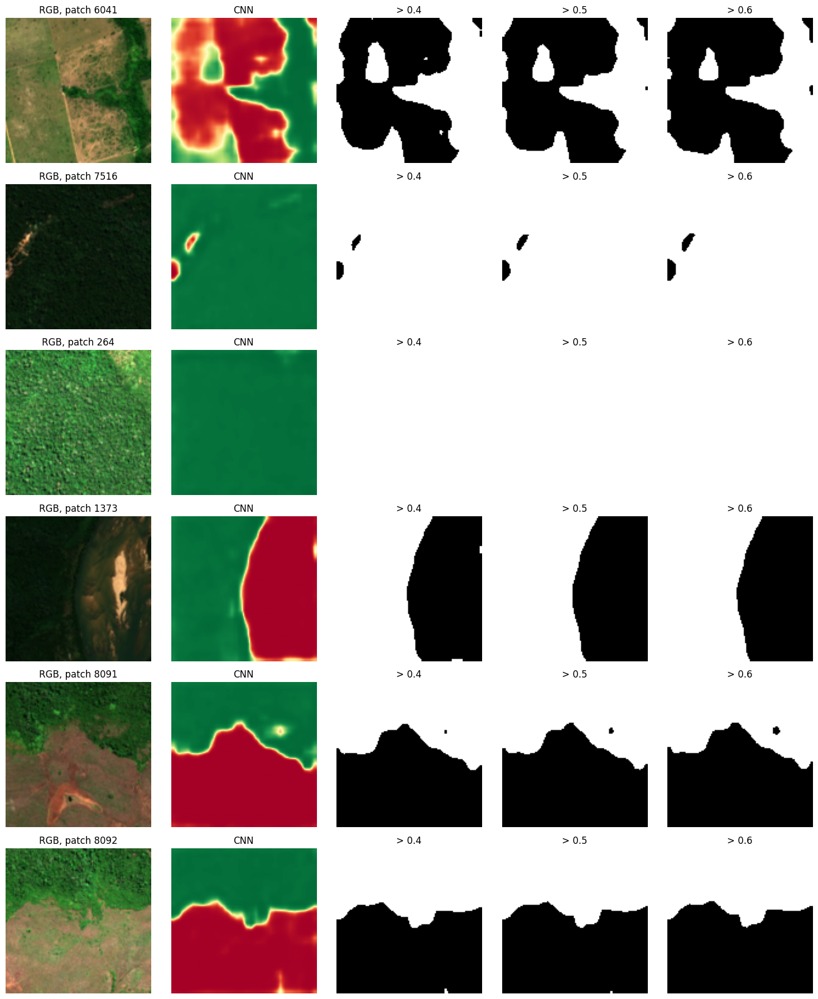

In [30]:
patch_means = cnn_probs_2018.mean(axis=(1, 2))
patch_stds = cnn_probs_2018.std(axis=(1, 2))

indices = [
    np.argmin(abs(patch_means - np.quantile(patch_means, q)))
    for q in [0.1, 0.5, 0.9]
]
high_std_indices = np.argsort(patch_stds)[-3:][::-1]
indices = list(dict.fromkeys([*indices, *high_std_indices]))

def plot_threshold_examples(patches, scores, indices, thresholds):
    rows = len(indices)
    cols = 2 + len(thresholds)

    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))

    for row, index in enumerate(indices):
        patch = patches[index]
        score = scores[index]

        rgb = patch[[2, 1, 0]].transpose(1, 2, 0)
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

        axes[row, 0].imshow(rgb)
        axes[row, 0].set_title(f"RGB, patch {index}")

        axes[row, 1].imshow(score, vmin=0, vmax=1, cmap="RdYlGn")
        axes[row, 1].set_title("CNN")

        for col, threshold in enumerate(thresholds, start=2):
            axes[row, col].imshow(score > threshold, vmin=0, vmax=1, cmap="gray")
            axes[row, col].set_title(f"> {threshold}")

        for ax in axes[row]:
            ax.axis("off")

    plt.tight_layout()

plot_threshold_examples(
    patches_2018,
    cnn_probs_2018,
    indices,
    thresholds=[0.4, 0.5, 0.6],
)

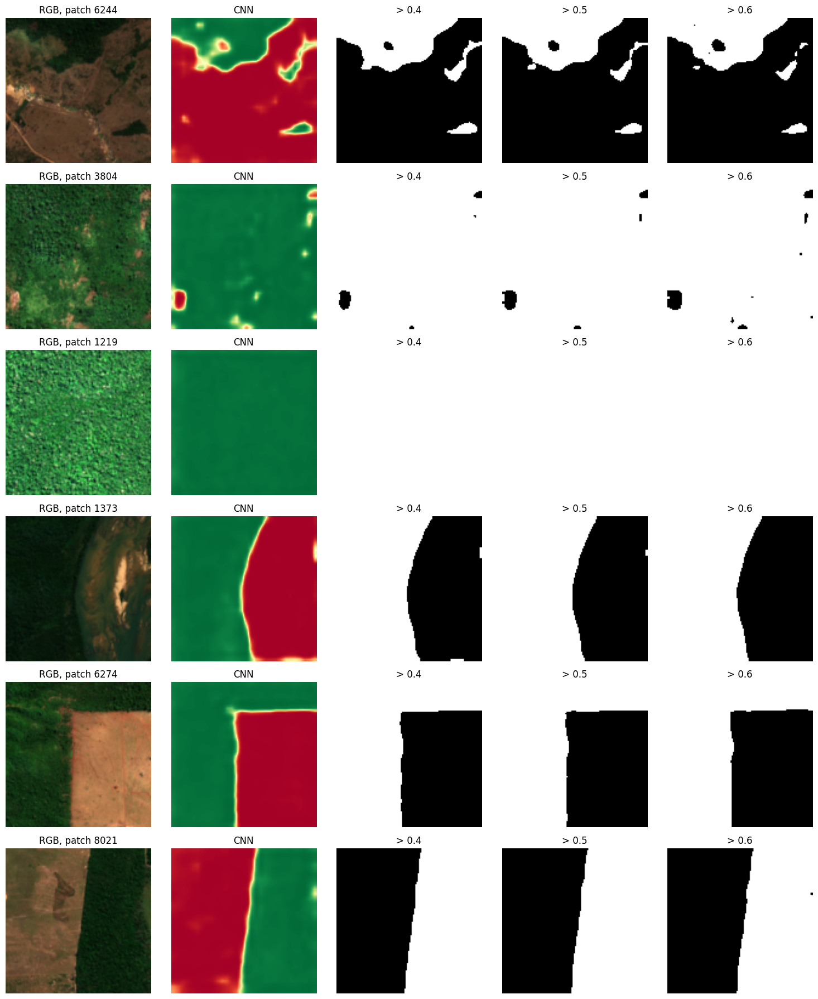

In [31]:
patch_means = cnn_probs_2024.mean(axis=(1, 2))
patch_stds = cnn_probs_2024.std(axis=(1, 2))

indices = [
    np.argmin(abs(patch_means - np.quantile(patch_means, q)))
    for q in [0.1, 0.5, 0.9]
]
high_std_indices = np.argsort(patch_stds)[-3:][::-1]
indices = list(dict.fromkeys([*indices, *high_std_indices]))

def plot_threshold_examples(patches, scores, indices, thresholds):
    rows = len(indices)
    cols = 2 + len(thresholds)

    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))

    for row, index in enumerate(indices):
        patch = patches[index]
        score = scores[index]

        rgb = patch[[2, 1, 0]].transpose(1, 2, 0)
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

        axes[row, 0].imshow(rgb)
        axes[row, 0].set_title(f"RGB, patch {index}")

        axes[row, 1].imshow(score, vmin=0, vmax=1, cmap="RdYlGn")
        axes[row, 1].set_title("CNN")

        for col, threshold in enumerate(thresholds, start=2):
            axes[row, col].imshow(score > threshold, vmin=0, vmax=1, cmap="gray")
            axes[row, col].set_title(f"> {threshold}")

        for ax in axes[row]:
            ax.axis("off")

    plt.tight_layout()

plot_threshold_examples(
    patches_2024,
    cnn_probs_2024,
    indices,
    thresholds=[0.4, 0.5, 0.6],
)

In [32]:
CNN_THRESHOLD = 0.5

A threshold of 0.5 was chosen because it is the natural decision boundary for binary probabilities. The CNN outputs were already strongly separated, so thresholds between 0.4 and 0.6 produced nearly identical masks.

##### <mark>CNN masks</mark>

In [33]:
cnn_masks_2018 = cnn_probs_2018 > CNN_THRESHOLD
cnn_masks_2024 = cnn_probs_2024 > CNN_THRESHOLD

if cnn_masks_2018.shape != cnn_masks_2024.shape:
    raise ValueError("2018 and 2024 CNN masks must have the same shape")

In [34]:
np.save(save_dir / "cnn_probs_2018.npy", cnn_probs_2018)
np.save(save_dir / "cnn_probs_2024.npy", cnn_probs_2024)

np.save(save_dir / "cnn_masks_2018.npy", cnn_masks_2018)
np.save(save_dir / "cnn_masks_2024.npy", cnn_masks_2024)

### 3.2.2 Change Detection and Forest Loss Computation

For both NDVI and CNN masks compute for the full tile (all patches):

- **Percentage loss:**  
  percentage_loss = 100 * (forest_pixels_2018 - forest_pixels_2024) / forest_pixels_2018

- **Absolute loss (m²):**  
  absolute_loss = (forest_pixels_2018 - forest_pixels_2024) * 100

where `forest_pixels_2018` and `forest_pixels_2024` are the number of forest pixels in 2018 and 2024, respectively. Each pixel represents 100 m² (10m resolution).

##### `compute_forest_loss(mask_2018, mask_2024, axis, pixel_area_m2)`

Params
```python
masks_{year}       # shape: [num_patches, 120, 120]
axis=None          # calculate the total forest area across all patches
axis=(1, 2)        # calculate the forest area for each patch (120 x 120) separately
pixel_area_m2=100  # wach pixel represents 100m² because the image resolution is 10m x 10m
```

In [35]:
def compute_forest_loss(
    mask_2018,
    mask_2024,
    axis=None,
    pixel_area_m2=100,
):
    # nonzero values are treated as forest
    forest_pixels_2018 = np.count_nonzero(mask_2018, axis=axis)
    forest_pixels_2024 = np.count_nonzero(mask_2024, axis=axis)
    # if axis=None, forest_pixels_{year} is a scalar
    # if axis=(1,2), forest_pixels_{year}.shape: (num_patches,)

    # positive: forest decrease
    # negative: forest increase
    forest_pixel_loss = forest_pixels_2018 - forest_pixels_2024

    # initialization of percentage loss with NaN(s)
    percentage_loss = np.full_like(np.asarray(forest_pixel_loss), np.nan, dtype=np.float64)
    # percentage_loss = 100 * forest_pixel_loss / forest_pixels_2018
    np.divide(
        100 * forest_pixel_loss,
        forest_pixels_2018,
        out=percentage_loss,
        where=forest_pixels_2018 > 0,
    )

    return {
        "forest_pixels_2018": forest_pixels_2018,
        "forest_pixels_2024": forest_pixels_2024,
        "forest_pixel_loss": forest_pixel_loss,
        "percentage_loss": percentage_loss,
        "absolute_loss_m2": forest_pixel_loss * pixel_area_m2,
    }

##### <mark>NDVI loss</mark>

In [36]:
ndvi_loss = compute_forest_loss(
    ndvi_masks_2018,
    ndvi_masks_2024,
)

print("NDVI Forest Loss")
print(f"  Forest pixels in 2018: {ndvi_loss['forest_pixels_2018']:,}")
print(f"  Forest pixels in 2024: {ndvi_loss['forest_pixels_2024']:,}")
print(f"  Forest pixel loss:     {ndvi_loss['forest_pixel_loss']:,}")
print(f"  Percentage loss:       {float(ndvi_loss['percentage_loss']):.2f}%")
print(f"  Absolute loss:         {ndvi_loss['absolute_loss_m2']:,.0f} m²")

NDVI Forest Loss
  Forest pixels in 2018: 109,795,542
  Forest pixels in 2024: 100,868,871
  Forest pixel loss:     8,926,671
  Percentage loss:       8.13%
  Absolute loss:         892,667,100 m²


##### <mark>CNN loss</mark>

In [37]:
cnn_loss = compute_forest_loss(
    cnn_masks_2018,
    cnn_masks_2024,
)

print("CNN Forest Loss")
print(f"  Forest pixels in 2018: {cnn_loss['forest_pixels_2018']:,}")
print(f"  Forest pixels in 2024: {cnn_loss['forest_pixels_2024']:,}")
print(f"  Forest pixel loss:     {cnn_loss['forest_pixel_loss']:,}")
print(f"  Percentage loss:       {float(cnn_loss['percentage_loss']):.2f}%")
print(f"  Absolute loss:         {cnn_loss['absolute_loss_m2']:,.0f} m²")

CNN Forest Loss
  Forest pixels in 2018: 99,703,433
  Forest pixels in 2024: 91,777,198
  Forest pixel loss:     7,926,235
  Percentage loss:       7.95%
  Absolute loss:         792,623,500 m²


### 3.2.3

For both NDVI and CNN plot the forest mask for the whole tile for 2018 and 2024. Annotate the plot with your calculated percentage and absolute loss. 
Hint: This can be resource heavy. Take a look at [garbage collection](https://docs.python.org/3/library/gc.html) or consider downsampling the data before plotting.


##### `reconstruct_full_mask(mask_patches, positions, usable_shape)`

In [38]:
def reconstruct_full_mask(mask_patches, positions, usable_shape):
    full_mask = np.zeros(usable_shape, dtype=bool)

    for patch, (top, left) in zip(mask_patches, positions):
        full_mask[
            top:top + PATCH_SIZE,
            left:left + PATCH_SIZE,
        ] = patch

    return full_mask # shape: usable_shape

##### `plot_full_masks(mask_2018, mask_2024, method, loss)`

In [39]:
def plot_full_masks(mask_2018, mask_2024, method, loss):
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    axes[0].imshow(mask_2018, cmap="gray")
    axes[0].set_title(f"{method} Forest Mask 2018")
    axes[0].axis("off")

    axes[1].imshow(mask_2024, cmap="gray")
    axes[1].set_title(f"{method} Forest Mask 2024")
    axes[1].axis("off")

    fig.suptitle(
        f"{method}: loss = {loss['percentage_loss']:.2f}% "
        f"({loss['absolute_loss_m2'] / 1e6:.2f} km²)"
    )

    plt.tight_layout()
    plt.show()

##### NDVI

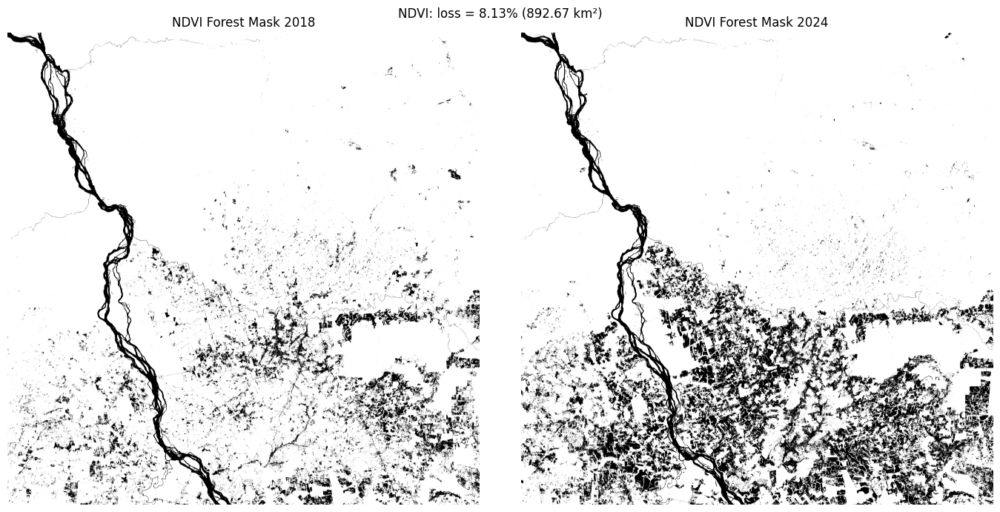

In [40]:
ndvi_full_mask_2018 = reconstruct_full_mask(ndvi_masks_2018, positions_2018, result_2018["usable_shape"])
ndvi_full_mask_2024 = reconstruct_full_mask(ndvi_masks_2024, positions_2024, result_2024["usable_shape"])

plot_full_masks(ndvi_full_mask_2018, ndvi_full_mask_2024, "NDVI", ndvi_loss)

##### CNN

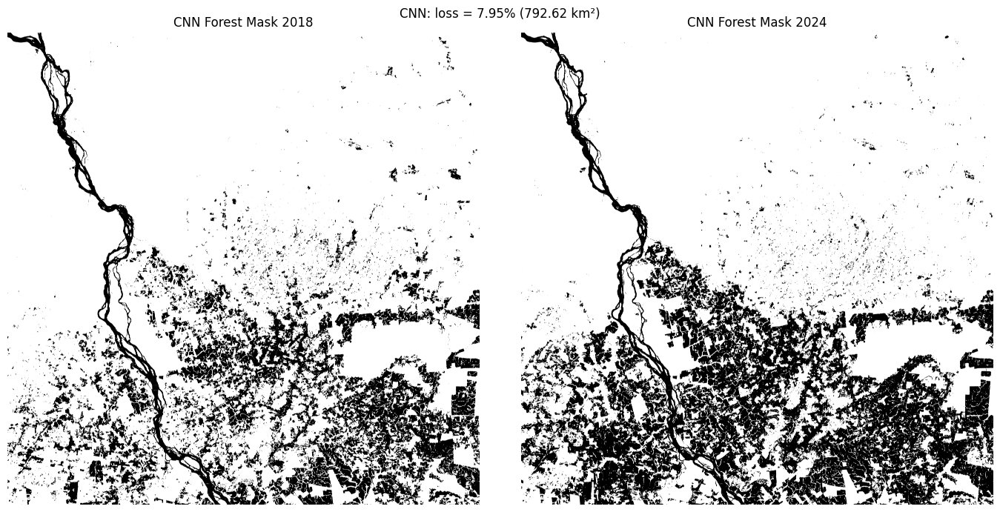

In [41]:
cnn_full_2018 = reconstruct_full_mask(cnn_masks_2018, positions_2018, result_2018["usable_shape"])
cnn_full_2024 = reconstruct_full_mask(cnn_masks_2024, positions_2024, result_2024["usable_shape"])

plot_full_masks(cnn_full_2018, cnn_full_2024, "CNN", cnn_loss)

##### Delete

In [43]:
del ndvi_full_mask_2018, ndvi_full_mask_2024

## 3.3 Extensive Qualitative Analysis

Select six representative patches:

- Two patches with high loss (one for CNN one for NDVI).
- Two patches with least loss or even negative loss (e.g. forest mask predicts more forest in 2024 then 2018) (one for CNN one for NDVI).
- Two patches with interesting discrepancies between methods.

For each patch plot:

- RGB composite for 2018 and 2024.
- CNN mask for 2018 and 2024.
- NDVI mask for 2018 and 2024.

Annotate each visualization with the computed percentage loss for both NDVI and CNN.



##### `select_unique_index(values, used_indices, largest)`

In [44]:
def select_unique_index(values, used_indices, largest=True):
    valid_indices = np.flatnonzero(np.isfinite(values))
    if len(valid_indices) == 0:
        raise ValueError("No valid patch available")

    sorted_positions = np.argsort(values[valid_indices])

    if largest:
        sorted_positions = sorted_positions[::-1]

    for position in sorted_positions:
        index = int(valid_indices[position])
        if index not in used_indices:
            used_indices.add(index)
            return index

    raise ValueError("No unused valid patch available")

##### Plot functions

In [45]:
def make_rgb(patch):
    # Band order: B04, B03, B02
    rgb = patch[[2, 1, 0]].transpose(1, 2, 0)

    lower = np.percentile(rgb, 2, axis=(0, 1), keepdims=True)
    upper = np.percentile(rgb, 98, axis=(0, 1), keepdims=True)

    rgb = (rgb - lower) / (upper - lower + 1e-8)

    return np.clip(rgb, 0, 1)

In [46]:
def plot_patch_comparison(index, label):
    rgb_2018 = make_rgb(patches_2018[index])
    rgb_2024 = make_rgb(patches_2024[index])

    top, left = positions_2018[index]

    fig, axes = plt.subplots(3, 2, figsize=(8, 11))

    # RGB
    axes[0, 0].imshow(rgb_2018)
    axes[0, 0].set_title("RGB 2018")

    axes[0, 1].imshow(rgb_2024)
    axes[0, 1].set_title("RGB 2024")

    # CNN masks
    axes[1, 0].imshow(cnn_masks_2018[index], cmap="gray", vmin=0, vmax=1)
    axes[1, 0].set_title("CNN Mask 2018")

    axes[1, 1].imshow(cnn_masks_2024[index], cmap="gray", vmin=0, vmax=1)
    axes[1, 1].set_title("CNN Mask 2024")

    # NDVI masks
    axes[2, 0].imshow(ndvi_masks_2018[index], cmap="gray", vmin=0, vmax=1)
    axes[2, 0].set_title("NDVI Mask 2018")

    axes[2, 1].imshow(ndvi_masks_2024[index], cmap="gray", vmin=0, vmax=1)
    axes[2, 1].set_title("NDVI Mask 2024")

    for ax in axes.flat:
        ax.axis("off")

    fig.suptitle(
        f"{label}\n"
        f"Patch {index}, position=({top}, {left})\n"
        f"NDVI loss: {ndvi_patch_losses[index]:.2f}% | "
        f"CNN loss: {cnn_patch_losses[index]:.2f}%",
        fontsize=13,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.91])
    plt.show()
    plt.close(fig)

##### Calculate losses

In [47]:
ndvi_patch_losses = compute_forest_loss(ndvi_masks_2018, ndvi_masks_2024, axis=(1, 2))["percentage_loss"]
cnn_patch_losses = compute_forest_loss(cnn_masks_2018, cnn_masks_2024, axis=(1, 2))["percentage_loss"]

print("NDVI losses shape:", ndvi_patch_losses.shape)  # num of patches
print("CNN losses shape:", cnn_patch_losses.shape)    # num of patches

NDVI losses shape: (8281,)
CNN losses shape: (8281,)


##### Select patches

In [48]:
used_indices = set()
selected_patches = []

selected_patches.append((
    "High NDVI loss",
    select_unique_index(ndvi_patch_losses, used_indices, largest=True),
))
selected_patches.append((
    "High CNN loss",
    select_unique_index(cnn_patch_losses, used_indices, largest=True),
))
selected_patches.append((
    "Low NDVI loss",
    select_unique_index(ndvi_patch_losses, used_indices, largest=False),
))
selected_patches.append((
    "Low CNN loss",
    select_unique_index(cnn_patch_losses, used_indices, largest=False),
))

loss_discrepancies = np.abs(ndvi_patch_losses - cnn_patch_losses)

selected_patches.append((
    "Large method discrepancy 1",
    select_unique_index(loss_discrepancies, used_indices, largest=True),
))
selected_patches.append((
    "Large method discrepancy 2",
    select_unique_index(loss_discrepancies, used_indices, largest=True),
))

In [49]:
for label, index in selected_patches:
    top, left = positions_2018[index]

    print(
        f"{label}: patch={index}, "
        f"position=({top}, {left}), "
        f"NDVI loss={ndvi_patch_losses[index]:.2f}%, "
        f"CNN loss={cnn_patch_losses[index]:.2f}%"
    )

High NDVI loss: patch=7340, position=(9600, 7200), NDVI loss=90.85%, CNN loss=81.84%
High CNN loss: patch=7453, position=(9720, 9840), NDVI loss=68.48%, CNN loss=100.00%
Low NDVI loss: patch=2543, position=(3240, 10320), NDVI loss=-199.45%, CNN loss=-200.46%
Low CNN loss: patch=7985, position=(10440, 8160), NDVI loss=-146.53%, CNN loss=-986.89%
Large method discrepancy 1: patch=7272, position=(9480, 9960), NDVI loss=-18.78%, CNN loss=-640.00%
Large method discrepancy 2: patch=7895, position=(10320, 8280), NDVI loss=-127.33%, CNN loss=-744.91%


#### High NDVI loss

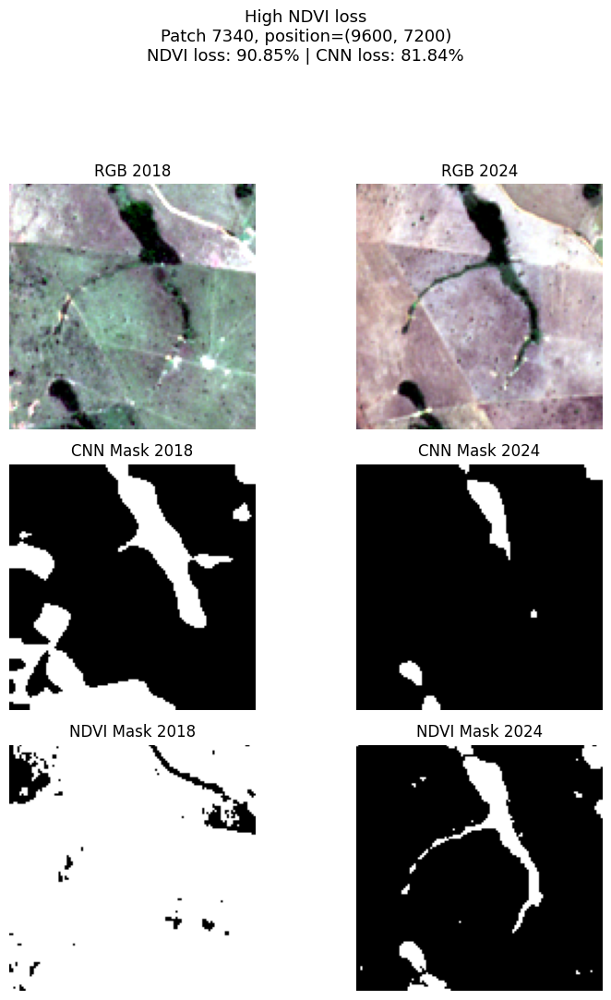

In [50]:
label, index = selected_patches[0]
plot_patch_comparison(index=index, label=label)

#### Hgih CNN loss

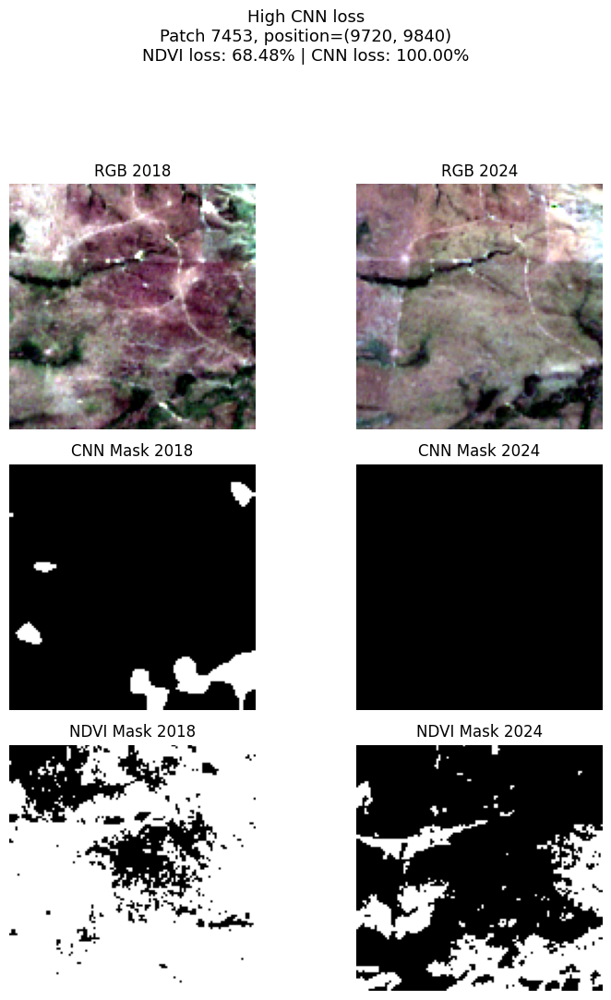

In [51]:
label, index = selected_patches[1]
plot_patch_comparison(index=index, label=label)

#### Low NDVI loss

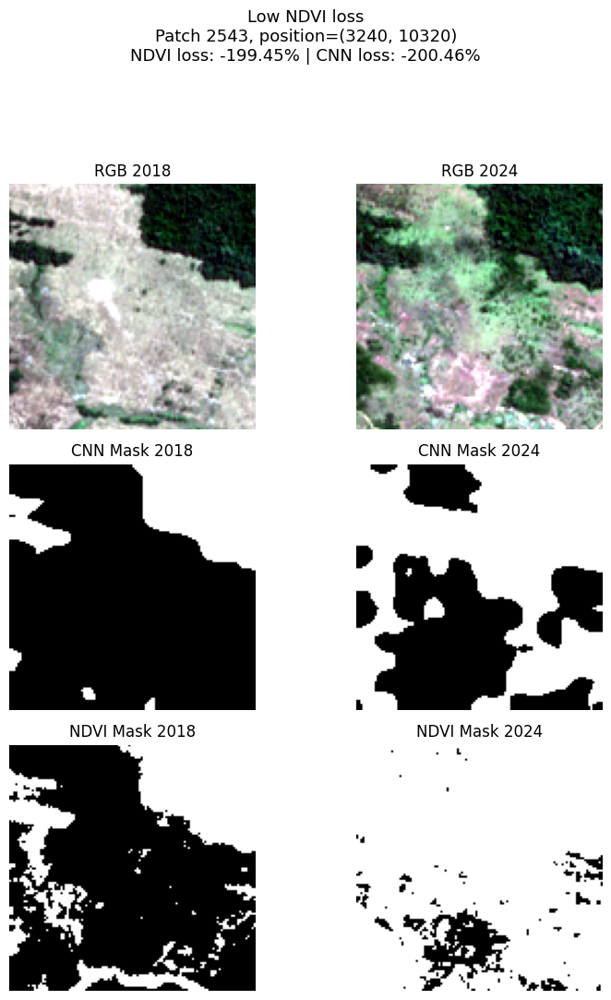

In [52]:
label, index = selected_patches[2]
plot_patch_comparison(index=index, label=label)

#### Low CNN loss

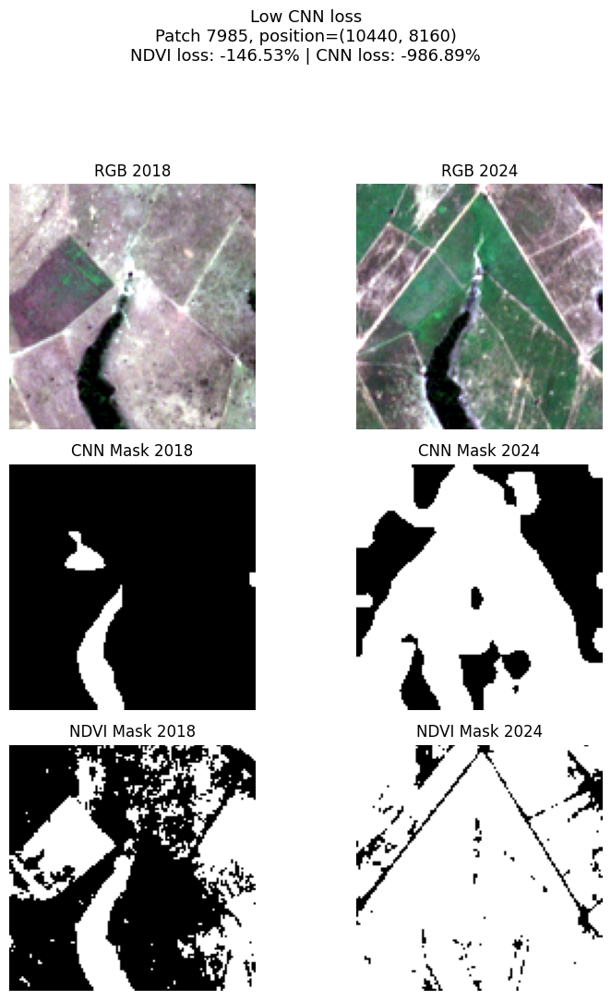

In [53]:
label, index = selected_patches[3]
plot_patch_comparison(index=index, label=label)

#### Large method discrepancy 1

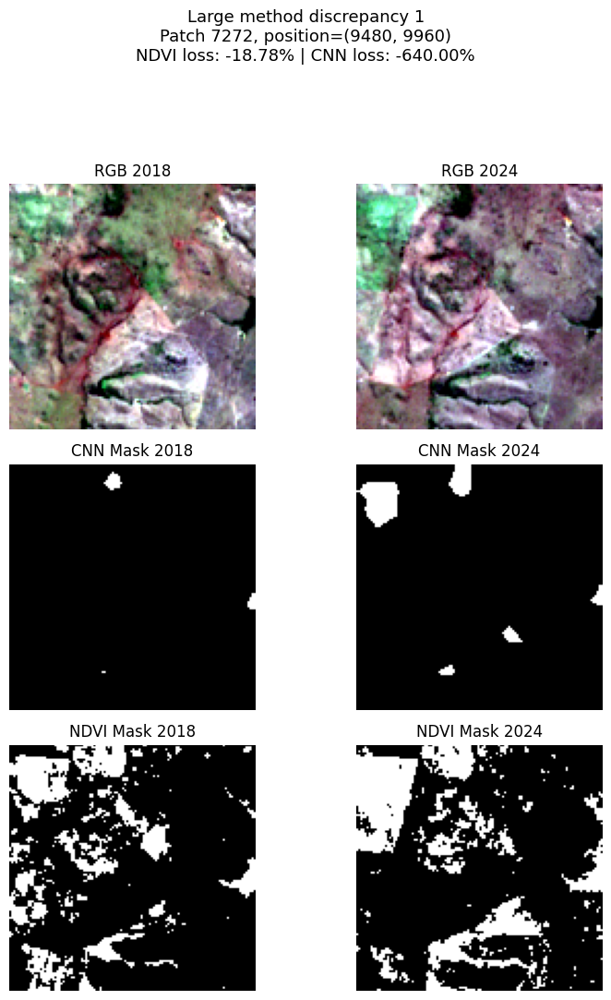

In [54]:
label, index = selected_patches[4]
plot_patch_comparison(index=index, label=label)

#### Large method discrepancy 2

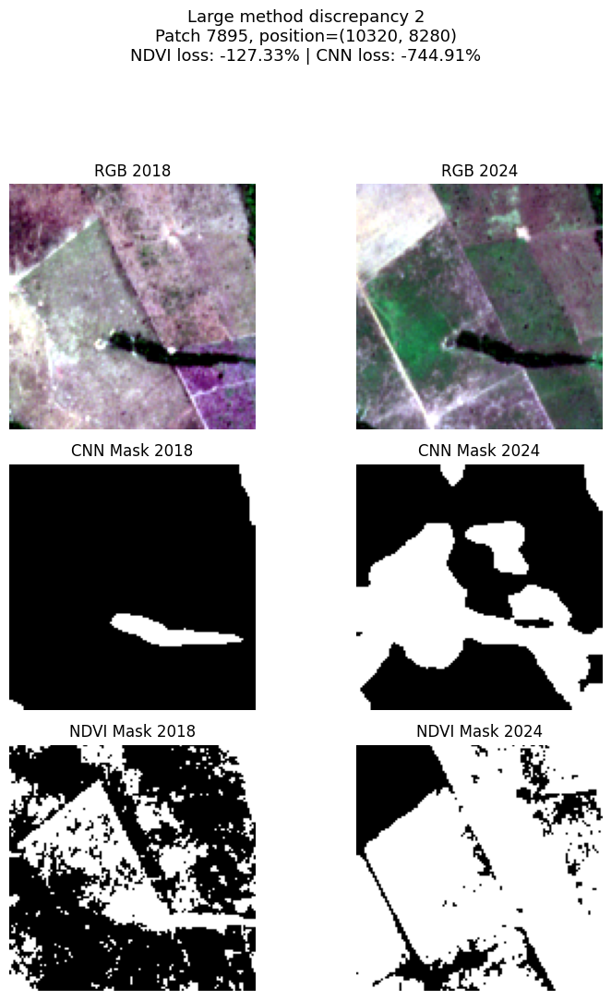

In [55]:
label, index = selected_patches[5]
plot_patch_comparison(index=index, label=label)

## 3.4 **Method Comparison and Interpretation**

Write a detailed qualitative evaluation (~500 words) discussing:

- Describe your plots
- Which method performed more robustly across varying conditions. Why
- Sensitivity to atmospheric noise, and classification errors.
- Advantages and limitations of both approaches.
- Possible improvements of both methods.
- Which method you would recommend for systematic deforestation assessment.



#### Plot description

The threshold plots compare RGB images with NDVI values or CNN probabilities and the resulting forest masks, where white indicates forest and black indicates non-forest.

For NDVI, thresholds of 0.25, 0.30, and 0.35 were tested. The choice had a clear effect on mixed and partially vegetated areas. Lower thresholds preserved more vegetation but also misclassified some bare ground as forest. A threshold of 0.30 provided the best balance.

The CNN masks changed little between thresholds of 0.40 and 0.60, suggesting that its predictions were less sensitive to threshold selection.

The reconstructed masks showed similar overall patterns, with most forest loss concentrated in the lower part of the tile. NDVI estimated a loss of 8.13% or 892.67 km², while the CNN estimated 7.95% or 792.62 km². Although the estimates differed by about 100 km², both methods identified a similar overall pattern and scale of forest loss.


#### Robustness and sensitivity

The CNN appeared more robust across different land-cover conditions because its masks were generally smoother and more spatially consistent. This may be because it uses multiple spectral bands together with surrounding spatial information, making it less sensitive to small variations in individual pixels. NDVI, by comparison, depends only on the red and near-infrared bands. However, smoother masks are not necessarily more accurate, especially because no independent ground-truth data were available.

The selected patches showed that the methods often agreed on the general direction of change but differed in magnitude. For the patch with the highest NDVI loss, NDVI estimated a 90.85% reduction, while the CNN estimated 81.84%. For the patch with the highest CNN loss, the estimates were 68.48% and 100%, respectively. These results suggest that both methods detected substantial forest loss, although the exact percentage depended strongly on the classification method.

Atmospheric and seasonal effects were not evaluated directly, but changes in red or near-infrared reflectance could cause NDVI values to cross the chosen threshold. The CNN also produced questionable results. In two discrepancy patches, NDVI estimated gains of 18.78% and 127.33%, while the CNN estimated much larger gains of 640.00% and 744.91%. Another patch produced a CNN loss of −986.89%. These extreme percentages were partly caused by the very small forest areas predicted for 2018, making moderate increases in 2024 appear unusually large. Because the RGB images did not clearly confirm that these areas had become forest, the results are better interpreted as possible classification inconsistencies rather than definite forest recovery.

#### Pros & cons, and improvements

NDVI is simple, transparent, and easy to reproduce, but it detects vegetation rather than forest specifically. It may therefore confuse forests with crops or other vegetation, and its performance depends strongly on the selected threshold. The most important improvements would be atmospheric correction and the use of adaptive thresholds.

The CNN produces more coherent forest boundaries by using richer spectral and spatial information. However, it requires labelled training data, is less interpretable, and may be affected by domain shift. The most important improvements would be more representative training data and augmentation for atmospheric variation.


#### Recommendation

The CNN is the better primary method because its predictions are more spatially consistent and less sensitive to threshold selection. However, it should still be validated with independent reference data. NDVI can serve as a simple secondary check for uncertain areas.
